## Лаборатона робота №3

**Виконали:**
- Сачек Владислава КА-31
- Богданова Олександра КА-32
- Плахтій Злата КА-32

**Хід роботи:**
1. Завантажити початковi данi.
2. Представити данi графiчно.
3. Iнiцiалiзувати параметри: швидкiсть навчання, кiлькiсть епох (=100) i додатково, якщо задано згiдно з варiантом, кiлькiсть пакетiв i/або параметр регуляризацiї.
4. Iнiцiалiзувати вектор параметрiв.
5. Реалiзувати функцiю, яка задає модель, наприклад:
• лiнiйну регресiю,
• полiномiальну регресiю,
• iншу криву, яку пiдiбрати вiдповiдно до заданих даних.
6. Задати функцiю втрат (одну згiдно з варiантом):
• MSE,
• MSE з регуляризацiєю за нормами L1 або L2.
7. Задати операцiю, яка буде викликатися на кожнiй iтерацiї алгоритма
навчання:
• алгоритм стохастичного градiєнтного спуску,
• алгоритм мiнi-пакетного градiєнтного спуску,
• алгоритм стохастичного градiєнтного спуску з моментом,
• алгоритм Adagrad,
• алгоритм Adadelta,
• алгоритм Adam.
8. Виконати навчання моделi.
9. Виводити значення функцiї втрат через кожнi 10 епох.
10. Зберегти контрольнi точки через регулярнi iнтервали пiд час навчання. В кiнцi навчання зберегти результуючу модель. Вiдновити останню контрольну точку при запуску,якщо навчання було перервано.
11. Налаштувати гiперпараметр швидкiсть навчання i додатково, якщо задано згiдно варiанту, розмiр мiнi-пакета. Подивитися на форму кривої навчання.
12. Дослiдити рiзнi значення параметра регуляризацiї i пiдiбрати найкраще з них, якщо згiдно з варiантом задано регуляризовану функцiю втрат. В цьому випадку данi мають бути попередньо розбитi на навчальний та перевiрочний набори.
13. Побудувати графiк з початковими даними та лiнiєю регресiї.

**Варіант 2**

Полiномiальна регресiя, алгоритм градiєнтного спуску за мiнi-батчами, MSE з регуляризацiєю за нормою L2.

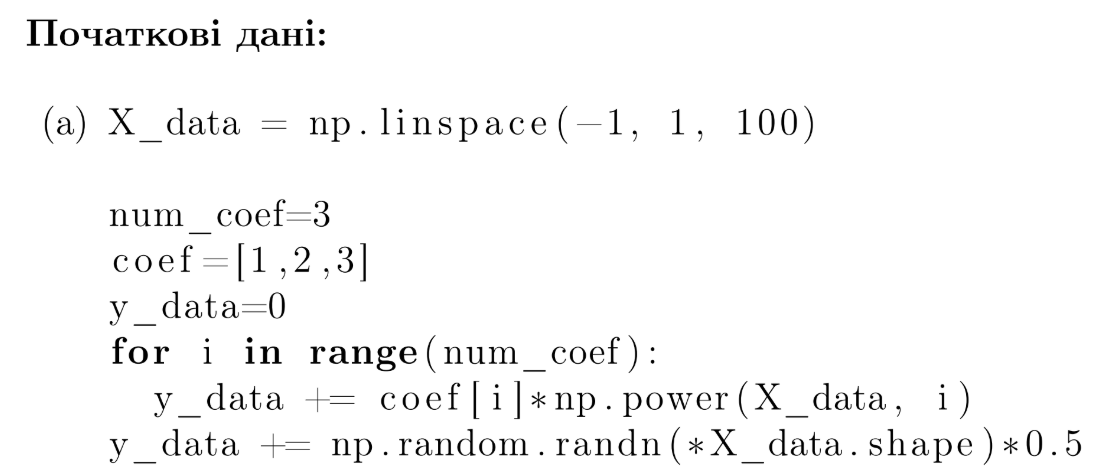

### Генерація даних
Дані генеруються за формулою поліному другого степеня:

**y = 1 + 2x + 3x² + ε**, де ε ~ N(0, 0.5)

Точок: 100, рівномірно на відрізку [-1, 1].

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

X_data = np.linspace(-1, 1, 100)

num_coef = 3
coef = [1, 2, 3]

y_data = 0
for i in range(num_coef):
    y_data += coef[i] * np.power(X_data, i)

y_data += np.random.randn(*X_data.shape) * 0.5

print("Розмір X:", X_data.shape)
print("Розмір y:", y_data.shape)
print("Перші 5 значень X:", X_data[:5].round(3))
print("Перші 5 значень y:", y_data[:5].round(3))

Розмір X: (100,)
Розмір y: (100,)
Перші 5 значень X: [-1.    -0.98  -0.96  -0.939 -0.919]
Перші 5 значень y: [1.84  1.364 2.509 2.346 1.197]


### Візуалізація даних

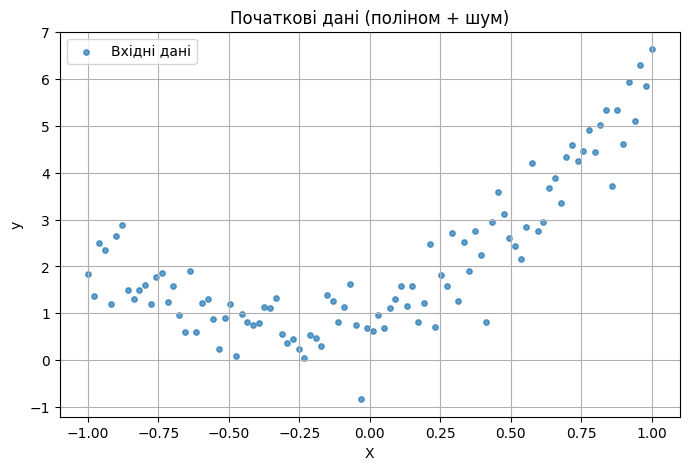

In [2]:
plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, s=15, alpha=0.7, label="Вхідні дані")
plt.title("Початкові дані (поліном + шум)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

На графіку видно характерну форму параболи із шумом.
У лівій частині (-1 .. 0) значення y низькі та розкидані,
у правій (0.5 .. 1) — швидко зростають до 5–6.
Це відповідає очікуваній поведінці поліному 1 + 2x + 3x².

### Гіперпараметри

In [ ]:
learning_rate = 0.01   
epochs        = 100    
batch_size    = 20     # розмір міні-батча (100/20 = 5 батчів)
lambda_l2     = 0.001  # параметр L2-регуляризації

### Ініціалізація вектора параметрів та Dataset

Вектор параметрів θ = [w₀, w₁, w₂] розміром (3, 1) ініціалізується
нулями як `tf.Variable` — це навчувані параметри моделі.

`tf.data.Dataset` формується з оригінального вектора X (не розширеного),
перемішується та розбивається на батчі по 20 зразків → 5 батчів на епоху.

In [ ]:
# Конвертуємо у тензори
X_tensor = tf.cast(X_data, tf.float32)
y_tensor = tf.cast(y_data, tf.float32)

# Ініціалізація вектора параметрів
theta = tf.Variable(tf.zeros([3, 1], dtype=tf.float32), name="theta")
print("Початкові θ:", theta.numpy().flatten())

# Dataset з оригінальним X (не розширеним)
dataset = tf.data.Dataset.from_tensor_slices((X_tensor, y_tensor))
dataset = dataset.shuffle(buffer_size=100, seed=42).batch(batch_size)

print(f"Кількість батчів: {len(list(dataset))}")

Початкові θ: [0. 0. 0.]
Кількість батчів: 5


### Клас моделі

Клас `PolynomialModel` наслідує `tf.keras.Model`.

Метод `call()` виконує два кроки:
1. Будує матрицю ознак всередині моделі: [1, x, x²] → форма (batch, 3)
2. Обчислює передбачення: ŷ = X_poly @ θ, після чого застосовує
   `tf.squeeze` для приведення форми з (batch, 1) до (batch,) —
   що відповідає формі y і дозволяє коректно обчислити MSE у наступній частині.

In [ ]:
class PolynomialModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.theta = theta

    def call(self, x):
        # Будуємо матрицю ознак [1, x, x²] всередині моделі
        X_poly = tf.stack([
            tf.ones_like(x),
            x,
            x ** 2
        ], axis=1)                          # (batch, 3)
        y_pred = tf.matmul(X_poly, self.theta)  # (batch, 1)
        return tf.squeeze(y_pred, axis=1)       # (batch,) 


model = PolynomialModel()

# Перевірка
for X_batch, y_batch in dataset.take(1):
    y_pred = model(X_batch)
    print("Форма батча X     :", X_batch.shape)
    print("Форма батча y     :", y_batch.shape)
    print("Форма передбачення:", y_pred.shape)   
    print("Початкові θ       :", model.theta.numpy().flatten())

Форма батча X     : (20,)
Форма батча y     : (20,)
Форма передбачення: (20,)
Початкові θ       : [0. 0. 0.]


### Функція втрат MSE з L2-регуляризацією
Визначимо за формулою:
$$J(θ) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\|θ\|_2^2,$$

де перший доданок - середньоквадратична помилка MSE, другий - штраф L2 за велику норму вектора параметрів, який стримує зростання параметрів і таким чином запобігає перенавчанню, тобто $J(θ) = MSE + L2Penalty$.   
Використовуємо параметр регуляризації $\lambda$, заданий раніше.

In [6]:
def mse_loss_l2(y_true, y_pred, theta, lambda_l2):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    l2_penalty = lambda_l2 * tf.reduce_sum(tf.square(theta))
    return mse + l2_penalty

### Операція міні-пакетного градієнтного спуску

Створюємо оптимізатор tf.optimizers.SGD із заданим learning_rate = 0.01.
На кожній ітерації:
1. Обчислюємо передбачення моделі на поточному батчі і значення функції втрат (MSE з L2-регуляризацією) усередині tape.
3. За допомогою tf.GradientTape знаходимо градієнти: TensorFlow «розмотує» tape у зворотному напрямку і обчислює ∂J/∂θ.
4. Оновлюємо параметри у напрямку, протилежному градієнту функції втрат: θ <- θ − η * ∇J(θ).

In [7]:
optimizer = tf.optimizers.SGD(learning_rate=learning_rate)

def train_step(model, X_batch, y_batch, lambda_l2):
    with tf.GradientTape() as tape:
        y_pred = model(X_batch)
        loss = mse_loss_l2(y_batch, y_pred, model.theta, lambda_l2)

    gradients = tape.gradient(loss, [model.theta])
    optimizer.apply_gradients(zip(gradients, [model.theta]))
    return loss.numpy()

### Навчання моделі 
На кожній епосі проходимо по всіх 5 батчах датасету, на кожному виконуємо train_step, накопичуємо loss і в кінці рахуємо середній loss за епоху. Кожні 10 епох виводимо значення функцiї втрат.

In [8]:
theta.assign(tf.zeros([3, 1], dtype=tf.float32))

history = []  

for epoch in range(1, epochs + 1):
    epoch_loss = 0.0
    num_batches = 0

    for X_batch, y_batch in dataset:
        batch_loss = train_step(model, X_batch, y_batch, lambda_l2)
        epoch_loss += batch_loss
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Епоха {epoch:3d}/{epochs}  |  Loss = {avg_loss:.6f}")

print(f"Фінальні θ: {model.theta.numpy().flatten().round(4)}")
print(f"Очікувані:  [1, 2, 3]")

Епоха   1/100  |  Loss = 6.501496
Епоха  10/100  |  Loss = 2.064021
Епоха  20/100  |  Loss = 1.154308
Епоха  30/100  |  Loss = 0.867761
Епоха  40/100  |  Loss = 0.718030
Епоха  50/100  |  Loss = 0.624998
Епоха  60/100  |  Loss = 0.561848
Епоха  70/100  |  Loss = 0.514146
Епоха  80/100  |  Loss = 0.478127
Епоха  90/100  |  Loss = 0.449731
Епоха 100/100  |  Loss = 0.426671
Фінальні θ: [1.3757 1.8635 2.174 ]
Очікувані:  [1, 2, 3]


На першій епосі loss має достатньо велике значення, далі швидко падає, а з 30-ї епохи падіння уповільнюється, бо градієнти стають меншими, і відповідно кожен крок дає менше покращення.

Отримані параметри відрізняються від очікуваних, тобто 100 епох із learning_rate = 0.01 виявилось недостатньо для повної збіжності, потрібно або більше епох, або збільшити швидкість навчання.

#### Крива навчання

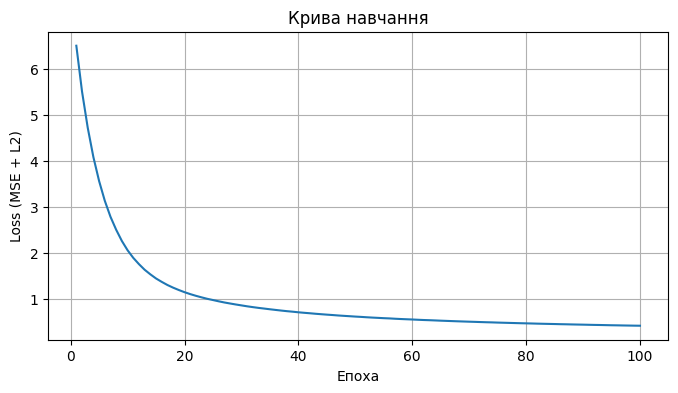

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), history, linewidth=1.5)
plt.xlabel("Епоха")
plt.ylabel("Loss (MSE + L2)")
plt.title("Крива навчання")
plt.grid(True)
plt.show()

Крива навчання має форму спадної експоненти, тобто loss монотонно спадає.